In [ ]:
# Implementation for Hope Speech Detection Shared Task – Task 2
# ======================================
# Task 2 – Run 1 (Single Run)
# Model: Logistic Regression
# Feature Representation: TF-IDF
# ======================================
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/Finegrained_train_data.csv")
test_df = pd.read_csv("/content/drive/MyDrive/Finegrained_test_data_withoutlabel.csv")


In [ ]:
X = train_df["Text"]
y = train_df["Label"]


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
vectorizer = TfidfVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)


LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_val_vec)

print(classification_report(y_val, y_pred))


                 precision    recall  f1-score   support

    fading hope       0.00      0.00      0.00        51
   hopelessness       0.45      0.72      0.56       167
 inspiring hope       0.59      0.73      0.65       249
optimistic hope       0.40      0.18      0.25        66
 realistic hope       0.18      0.05      0.08       104

       accuracy                           0.50       637
      macro avg       0.32      0.34      0.31       637
   weighted avg       0.42      0.50      0.44       637



In [ ]:
X_full_vec = vectorizer.fit_transform(X)
model.fit(X_full_vec, y)


LogisticRegression(max_iter=1000)

In [ ]:
X_test_vec = vectorizer.transform(test_df["Text"])
test_predictions = model.predict(X_test_vec)


In [ ]:
submission = pd.DataFrame({
    "label": test_predictions
})

submission.to_csv("SJM_MINDS_Tulu.csv", index=False)
submission.head()


,label
0,hopelessness
1,hopelessness
2,hopelessness
3,inspiring hope
4,optimistic hope


In [ ]:
# Count the number of occurrences of each label in the Train dataset
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Finegrained_train_data.csv")



label_counts = df['Label'].value_counts()

print(label_counts)

Label
inspiring hope     1129
hopelessness        937
realistic hope      503
optimistic hope     380
fading hope         236
Name: count, dtype: int64


In [ ]:
# Count the number of occurrences of each label in the Development dataset
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Finegrained_dev_data.csv")


label_counts = df['Label'].value_counts()

print(label_counts)

Label
inspiring hope     242
hopelessness       200
realistic hope     108
optimistic hope     81
fading hope         51
Name: count, dtype: int64


In [ ]:
# Count the number of occurrences of each label in the Test dataset
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Finegrained_test_data.csv")



label_counts = df['Label'].value_counts()

print(label_counts)

Label
inspiring hope     242
hopelessness       201
realistic hope     108
optimistic hope     82
fading hope         50
Name: count, dtype: int64


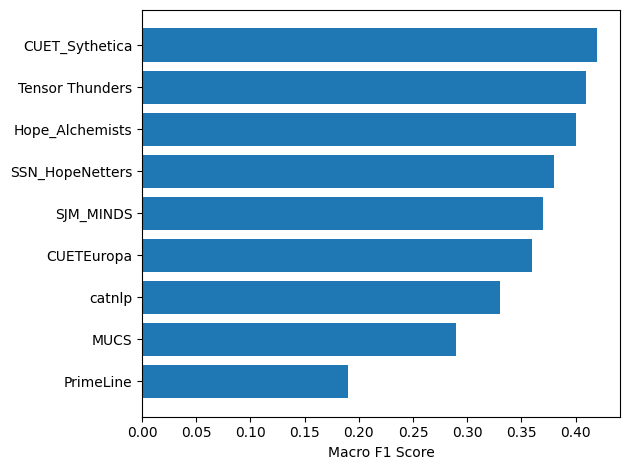

In [ ]:
#Visual Representation of leaderboard results for Task 2
import matplotlib.pyplot as plt

teams = ["PrimeLine", "MUCS", "catnlp", "CUETEuropa",
         "SJM_MINDS", "SSN_HopeNetters",
         "Hope_Alchemists", "Tensor Thunders",
         "CUET_Sythetica"]

scores = [0.19, 0.29, 0.33, 0.36, 0.37, 0.38, 0.40, 0.41, 0.42]

plt.figure()
plt.barh(teams, scores)
plt.xlabel("Macro F1 Score")
plt.tight_layout()
plt.savefig("leaderboard_results2.png", dpi=300)
plt.show()

In [ ]:
from google.colab import files
files.download("leaderboard_results2.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

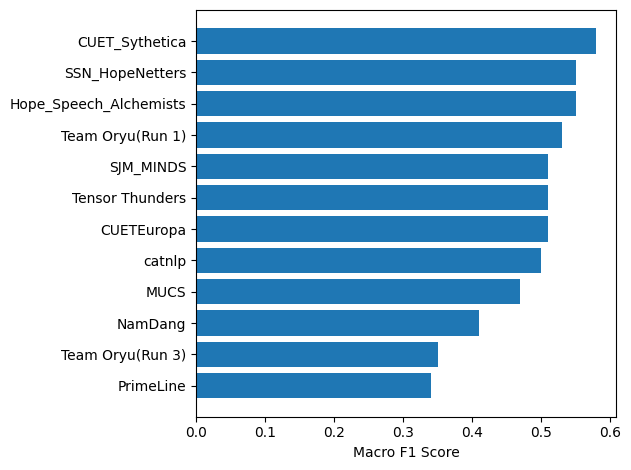

In [ ]:
#Visual Representation of leaderboard results for Task 1

import matplotlib.pyplot as plt

teams = ["PrimeLine","Team Oryu(Run 3)", "NamDang", "MUCS","catnlp","CUETEuropa",
         "Tensor Thunders","SJM_MINDS","Team Oryu(Run 1)","Hope_Speech_Alchemists","SSN_HopeNetters",
         "CUET_Sythetica"]

scores = [0.34,0.35,0.41, 0.47, 0.50, 0.51, 0.51, 0.51, 0.53,0.55,0.55,0.58]

plt.figure()
plt.barh(teams, scores)
plt.xlabel("Macro F1 Score")
plt.tight_layout()
plt.savefig("leaderboard_results1.png", dpi=300)
plt.show()

In [ ]:
from google.colab import files
files.download("leaderboard_results1.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

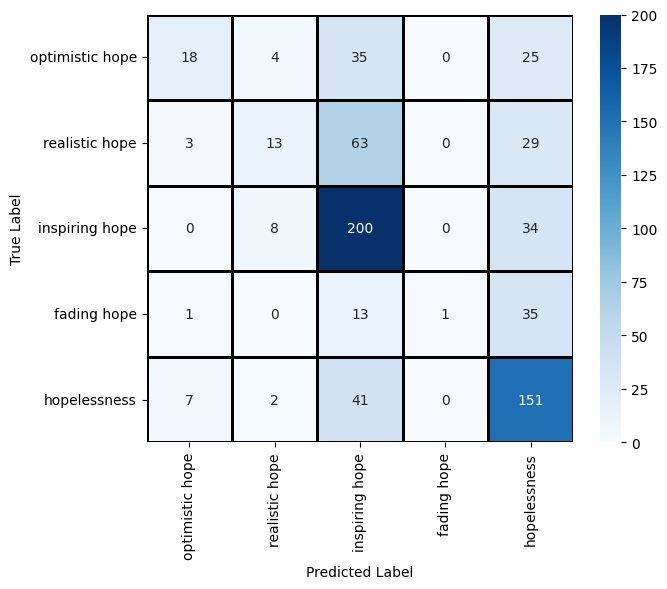

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Confusion Matrix for Task 2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

true = pd.read_csv("/content/drive/MyDrive/Finegrained_test_data_label.csv")
pred = pd.read_csv("/content/drive/MyDrive/SJM_MINDS_Tulu_Run1.csv")

y_true = true["Label"]
y_pred = pred["label"]

labels = ["optimistic hope", "realistic hope", "inspiring hope", "fading hope", "hopelessness"]

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    linewidths=1,
    linecolor="black"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.savefig("task2_confusion_matrix.png", dpi=400)

plt.show()

from google.colab import files
files.download("task2_confusion_matrix.png")

In [ ]:
#Error Analysis:Misclassification Samples
y_pred_task2 = model.predict(X_test_vec)

In [ ]:


test_data = pd.read_csv("/content/drive/MyDrive/Finegrained_test_data_label.csv")

In [ ]:
print(test_data.columns)

Index(['Text', 'Label'], dtype='object')


In [ ]:
pred = pd.read_csv("/content/drive/MyDrive/SJM_MINDS_Tulu.csv")

In [ ]:
error_df = pd.DataFrame({
    "Text": test_data["Text"],
    "Actual": test_data["Label"],
    "Predicted": y_pred_task2
})

In [ ]:
errors = error_df[error_df["Actual"] != error_df["Predicted"]]

print("Total Errors:", len(errors))

errors.head(40)

Total Errors: 300


,Text,Actual,Predicted
1,"Dislike dhaye malpuvar,,,, support malpule nam...",optimistic hope,hopelessness
3,Must ista apune nikl comedy..super ya,optimistic hope,inspiring hope
4,My name is annapa tulu movie upload manpule br...,hopelessness,optimistic hope
5,Porlu undu marre,realistic hope,inspiring hope
7,Banji g hakorchi nataka pls...update manpule....,realistic hope,hopelessness
10,Super full episode paadle,hopelessness,inspiring hope
11,Nekk yer dislike mathini super Comedy,hopelessness,inspiring hope
17,Masth masth love from nitha,realistic hope,inspiring hope
19,Dhadhe endhu comadiya comady prassmsa nakln th...,fading hope,hopelessness
20,Voice not good.chakka na voice,fading hope,hopelessness


In [ ]:
errors.to_csv("error_analysis_task2.csv", index=False,encoding="utf-8-sig")
from google.colab import files
files.download("error_analysis_task2.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>